
# Оцінка та вдосконалення моделі


<h2>Мета</h2>

Ознайомитись з методами оцінки та вдосконалення регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Розділяти дані на навчальну та тестову вибірки
* Використовувати перехресну перевірку для оцінки якості моделі
* Обирати оптимальну складність моделі для уникнення перенавчання
* Вдосконалювати моделі прогнозування за допомогою підбору параметрів


<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачайте дані із файлу <a href="https://drive.google.com/file/d/1wSj5SKRPKOjNPP2cyqaNpxRCinKEmJkO/view?usp=drive_link" target="_blank">'clean_data2.csv'</a> (Data2.csv з виправленими помилками та заповненими пропусками). Запишіть дані у два датафрейми: предиктори (x_data) та відгуки (y_data). Випадковим чином розділіть дані на навчальні та тестові (використайте 20% загального набору в якості тестових даних).
2. Побудуйте модель лінійної одномірної регресії для одного з предикторів, використовуючи навчальні дані. Знайдіть R^2 на навчальних та тестових даних. Чому вони різні і на який з них треба орієнтуватись при виборі моделі?
3. Побудуйте кілька поліноміальних моделей різних ступенів для того ж предиктора. Знайдіть R^2 цих моделей на тестових даних. Яка з моделей краща? При якому ступені полінома спостерігається перенавчання?
4. Побудуйте модель гребеневої регресії для двох найкращих предикторів. Параметр alpha повинен бути встановлений на 10. Обчисліть R^2.
5. Виконайте пошук по сітці для параметра alpha та параметра нормалізації, а потім побудуйте модель, використавши найкращі значення параметрів.

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Запишіть дані у два датафрейми: предиктори (x_data) та відгуки (y_data). Випадковим чином розділіть дані на навчальні та тестові (використайте 20% загального набору в якості тестових даних).</p>
</div>


Зчитую дані з файлу у датафрейм


In [72]:
import pandas as pd

DATA_PATH = 'data/clean_data.csv'

df = pd.read_csv(DATA_PATH, sep=';', encoding='cp1252')

df[['country_name', 'region']] =  df[['country_name', 'region']].astype('string')
df.dtypes


country_name          string[python]
region                string[python]
gdp_per_capita                 int64
population                     int64
co2_emission                 float64
area                         float64
population_density           float64
dtype: object

Буду використовувати тільки числові дані


In [73]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
df=df._get_numeric_data()
df.head()

,gdp_per_capita,population,co2_emission,area,population_density
0,5617787463,34656032,9809.225,652860.0,53.083405
1,412498239,2876101,5716.853,28750.0,100.038296
2,3916881571,40606052,145400.217,2381740.0,17.048902
3,3698862203,77281,462.042,470.0,164.427660
4,3308700233,28813463,34763.160,1246700.0,23.111786


Записую дані у два датафрейми. x_data – предиктори, y_data - відгуки.

In [74]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
y_data = df["co2_emission"]
x_data = df.drop(columns=["co2_emission"], axis=1)


In [75]:
x_data

,gdp_per_capita,population,area,population_density
0,5617787463,34656032,652860.0,53.083405
1,412498239,2876101,28750.0,100.038296
2,3916881571,40606052,2381740.0,17.048902
3,3698862203,77281,470.0,164.427660
4,3308700233,28813463,1246700.0,23.111786
...,...,...,...,...
200,3675459700,31568179,912050.0,34.612334
201,2170648054,92701100,330967.0,280.091671
202,990334774,27584213,527970.0,52.245796
203,1269573537,16591390,752610.0,22.045136


In [76]:
y_data

0        9809.225
1        5716.853
2      145400.217
3         462.042
4       34763.160
          ...    
200    185220.170
201    166910.839
202     22698.730
203      4503.076
204     12020.426
Name: co2_emission, Length: 205, dtype: float64

Випадково розділяю дані на навчальні та тестові таким чином, щоб 20% використовувалося для тестування. 

In [77]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from sklearn.model_selection import train_test_split

x_train1, x_test1, y_train1, y_test1 = train_test_split(x_data, y_data, test_size=0.2, random_state=0)
print("number of test samples :", x_test1.shape[0])
print("number of training samples:",x_train1.shape[0])

number of test samples : 41
number of training samples: 164


<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель лінійної одномірної регресії для одного з предикторів, використовуючи навчальні дані. Знайдіть R^2 на навчальних та тестових даних. Чому вони різні і на який з них треба орієнтуватись при виборі моделі?</p>
</div>


<p>З попередніх робіт знаю, що хорошими показниками для 'CO2 emission' можуть бути:</p>
<ul>
    <li>population</li>
    <li>area</li>
</ul>
При цьому одномірна модель для population була кращою. Тому будуватиму моделі, використовуючи саме цю ознаку як предиктор.

<p>Створюю об’єкт лінійної регресії та навчаю модель</p>


In [78]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

Підбираю модель за ознакою population.

In [79]:
lr.fit(x_train1[['population']], y_train1)

LinearRegression()

Обчислюю R^2  на навчальних та тестових даних:


In [80]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
lr.score(x_train1[['population']], y_train1)

0.6519443515589283

In [81]:
lr.score(x_test1[['population']], y_test1)

0.36088454385551594

Різниця між значеннями R^2 на навчальних та тестових даних вказує на перенавчання. Модель може бути занадто складною, що ускладнює її здатність правильно узагальнювати нові дані, що призводить до зниження її точності на тестових даних.

При виборі моделі важливо враховувати її здатність точно прогнозувати на нових, невідомих даних. Тому оцінка ефективності моделі на тестових даних є критично важливою, оскільки саме ці дані найкраще показують її реальну продуктивність.

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей різних ступенів для того ж предиктора. Знайдіть R^2 цих моделей на тестових даних. Яка з моделей краща? При якому ступені полінома спостерігається перенавчання?</p>
</div>


Будую поліноміальну модель 2 ступеня, на тестових даних обчислюю R^2


In [82]:
from sklearn.preprocessing import PolynomialFeatures


# Виконую поліноміальне перетворення 2 ступеня для ознаки 'population'
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train1[['population']])
x_test_pr = pr.transform(x_test1[['population']])


# Будую поліноміальну модель
poly = LinearRegression()
poly.fit(x_train_pr, y_train1)

# На тестових даних обчислюю R^2
poly.score(x_test_pr, y_test1)


0.3481119390705474

In [83]:
# На навчальних даних обчислюю R^2
poly.score(x_train_pr, y_train1)

0.6527697142186664

Будую поліноміальну модель 3 ступеня, на тестових даних обчислюю R^2


In [84]:
# Виконую поліноміальне перетворення 3 ступеня для ознаки 'population'
pr = PolynomialFeatures(degree=3)
x_train_pr = pr.fit_transform(x_train1[['population']])
x_test_pr = pr.transform(x_test1[['population']])


# Будую поліноміальну модель
poly = LinearRegression()
poly.fit(x_train_pr, y_train1)


# На тестових даних обчислюю R^2
poly.score(x_test_pr, y_test1)


0.2057719755262588

In [85]:
# На навчальних даних обчислюю R^2
poly.score(x_train_pr, y_train1)

0.6101373658509217

Будую поліноміальну модель 4 ступеня, на тестових даних обчислюю R^2

In [86]:
# Виконую поліноміальне перетворення 4 ступеня для ознаки 'population'
pr = PolynomialFeatures(degree=4)
x_train_pr = pr.fit_transform(x_train1[['population']])
x_test_pr = pr.transform(x_test1[['population']])


# Будую поліноміальну модель
poly = LinearRegression()
poly.fit(x_train_pr, y_train1)


# На тестових даних обчислюю R^2
poly.score(x_test_pr, y_test1)


-0.11838582063388459

In [87]:
# На навчальних даних обчислюю R^2
poly.score(x_train_pr, y_train1)

0.650101206578765

Візуалізую моделі (зручно розміщувати всі моделі на одному графіку для обрання найкращої) та показник їх якості (доцільно побудувати графік залежності R^2 або MSE від порядку поліному моделі)

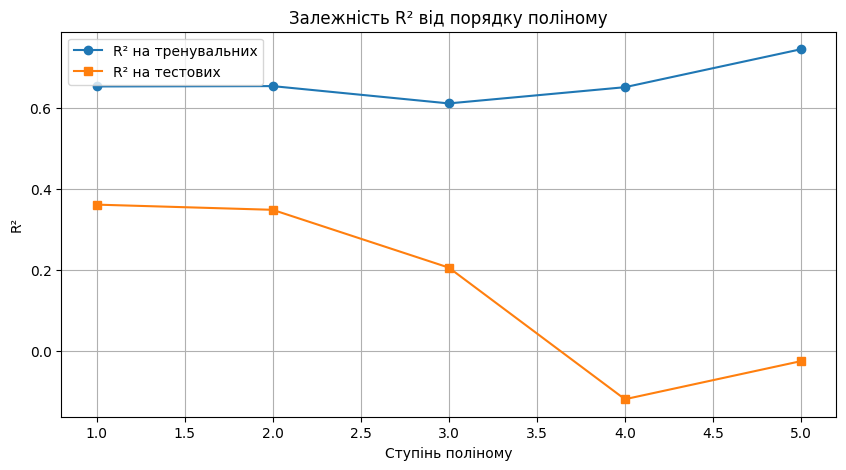

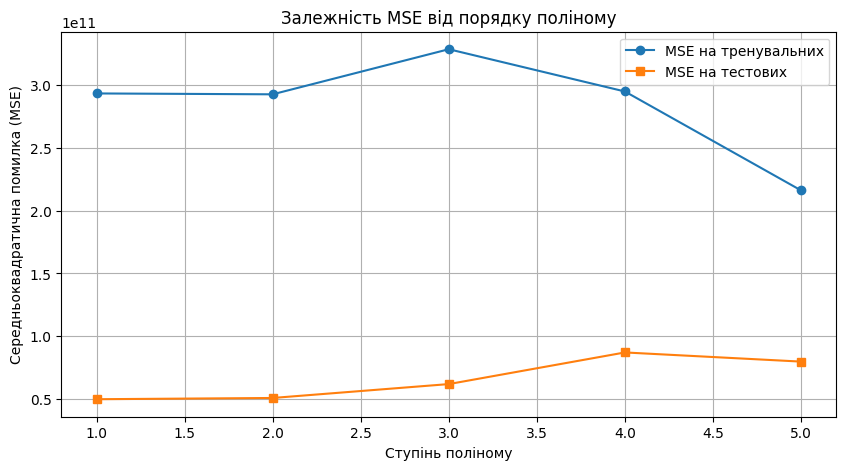

In [88]:
# Будую візуалізації моделей

# Будую візуалізацію залежності R^2 або MSE від порядку поліному моделі


import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

degrees = range(1, 6)
train_scores = []
test_scores = []
train_mse = []
test_mse = []

for degree in degrees:
    pr = PolynomialFeatures(degree=degree)
    x_train_pr = pr.fit_transform(x_train1[['population']])
    x_test_pr = pr.transform(x_test1[['population']])
    
    model = LinearRegression()
    model.fit(x_train_pr, y_train1)
    
    # R^2
    train_scores.append(model.score(x_train_pr, y_train1))
    test_scores.append(model.score(x_test_pr, y_test1))
    
    # MSE
    y_train_pred = model.predict(x_train_pr)
    y_test_pred = model.predict(x_test_pr)
    train_mse.append(mean_squared_error(y_train1, y_train_pred))
    test_mse.append(mean_squared_error(y_test1, y_test_pred))

# Візуалізація R^2
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_scores, marker='o', label='R² на тренувальних')
plt.plot(degrees, test_scores, marker='s', label='R² на тестових')
plt.title('Залежність R² від порядку поліному')
plt.xlabel('Ступінь поліному')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.show()

# Візуалізація MSE
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_mse, marker='o', label='MSE на тренувальних')
plt.plot(degrees, test_mse, marker='s', label='MSE на тестових')
plt.title('Залежність MSE від порядку поліному')
plt.xlabel('Ступінь поліному')
plt.ylabel('Середньоквадратична помилка (MSE)')
plt.legend()
plt.grid(True)
plt.show()



Зі зростанням порядку поліному модель краще підлаштовується під тренувальні дані, проте значно погіршується її здатність узагальнювати на тестових даних. Це проявляється у зменшенні R² та зростанні MSE на тестовій вибірці, що вказує на перенавчання. Найкращі результати на тестових даних спостерігаються для поліномів 1-го та 2-го порядку. Для уникнення перенавчання при використанні поліномів вищого порядку доцільно застосовувати методи регуляризації.


<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте модель гребеневої регресії для двох найкращих предикторів. Параметр alpha повинен бути встановлений на 10. Обчисліть R^2.</p>
</div>


Будую модель гребеневої регресії, обчислюю R^2


In [89]:
# Виконую поліноміальне перетворення 2 ступеня для двох обраних ознак
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train1[['population', 'area']])
x_test_pr = pr.transform(x_test1[['population', 'area']])

In [90]:
# Створюю об’єкт гребеневої регресії, встановивши параметр alpha=10
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline

ridge_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=10))

# Навчаю модель
ridge_pipeline.fit(x_train_pr, y_train1)


# Обчислення R^2
r2_train = ridge_pipeline.score(x_train_pr, y_train1)
r2_test = ridge_pipeline.score(x_test_pr, y_test1)

print(f"R^2 на тренувальних даних: {r2_train}")
print(f"R^2 на тестових даних: {r2_test}")


R^2 на тренувальних даних: 0.9204063948643332
R^2 на тестових даних: -2.4478260311644737


Бачимо, що R^2 для навчальних даних становить 0.9204, тоді як R^2 для тестових даних становиnm -2.4478. Чим менше R^2, тим гірша модель. Від’ємний R^2 є ознакою перенавчання.

Порівнюю перші п’ять прогнозованих значень із нашим тестовим набором:

In [91]:
yhat = ridge_pipeline.predict(x_test_pr)

In [92]:
print(f"predicted values: {yhat[0:5]}")
print(f"actual values: {y_test1[0:5].values}")

predicted values: [ 35738.40553706 111730.95171604  35347.5248125   35223.98133675
 136825.91905658]
actual values: [   722.399  11562.051    531.715    495.045 345981.45 ]


<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконайте пошук по сітці для параметра alpha та параметра нормалізації, а потім побудуйте модель, використавши найкращі значення параметрів.</p>
</div>


Створюю словник значень параметрів:


In [93]:
from sklearn.model_selection import  GridSearchCV

parameters = [
    {
        'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
    }
]

parameters

[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}]

Створюю об’єкт сітки пошуку параметра гребеневої регресії:


In [94]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
rr = Ridge()

grid = GridSearchCV(rr, parameters, cv=4)

Підбираю модель:


In [95]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
grid.fit(x_data[['population', 'area']], y_data)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    1000000]}])

Отримую модель з найкращими параметрами:


In [96]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
best_rr = grid.best_estimator_
best_rr

Ridge(alpha=1000000)

Тестую модель на тестових даних (обчислюю R^2):


In [97]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
best_rr.score(x_test1[['population', 'area']], y_test1)

0.43995719636098174

<a name="task6"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте візуалізації для оцінки якості моделей (лінійної, кращої з поліноміальних та кращої з гребеневих), всі розмістіть на одній координатній сітці для зручного порівняння.</p>
</div>


Використаю метод "predict", щоб спрогнозувати результати, а потім скористаюсь функцією "DistributionPlot", щоб відобразити розподіл прогнозованих результатів для тестових даних порівняно з фактичними для тестових даних.


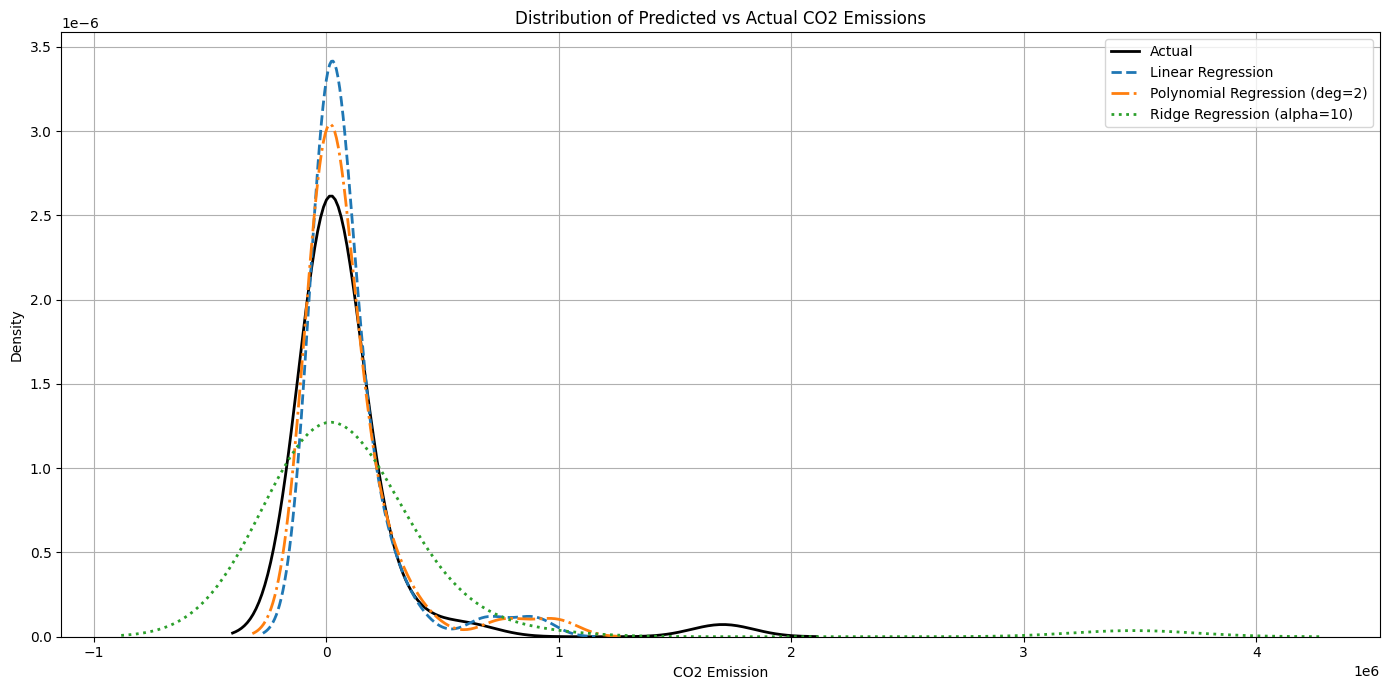

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

# --- Підготовка моделей ---

# 1. Лінійна модель
lr = LinearRegression()
lr.fit(x_train1[['population']], y_train1)
y_pred_linear = lr.predict(x_test1[['population']])

# 2. Поліноміальна модель (2-го ступеня, наприклад)
pr = PolynomialFeatures(degree=2)
x_train_poly = pr.fit_transform(x_train1[['population']])
x_test_poly = pr.transform(x_test1[['population']])

poly = LinearRegression()
poly.fit(x_train_poly, y_train1)
y_pred_poly = poly.predict(x_test_poly)

# 3. Гребенева модель (population + area)
ridge = Ridge(alpha=10)
ridge.fit(x_train1[['population', 'area']], y_train1)
y_pred_ridge = ridge.predict(x_test1[['population', 'area']])

# --- Візуалізація ---

plt.figure(figsize=(14, 7))

sns.kdeplot(y_test1, label='Actual', linewidth=2, color='black')
sns.kdeplot(y_pred_linear, label='Linear Regression', linestyle='--', linewidth=2)
sns.kdeplot(y_pred_poly, label='Polynomial Regression (deg=2)', linestyle='-.', linewidth=2)
sns.kdeplot(y_pred_ridge, label='Ridge Regression (alpha=10)', linestyle=':', linewidth=2)

plt.title("Distribution of Predicted vs Actual CO2 Emissions")
plt.xlabel("CO2 Emission")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>поліноміальна модель (ступінь 2)</b> є найкращою моделлю для прогнозування 'CO2 emission' на основі нашого набору даних. Вона найточніше повторює розподіл фактичних значень та краще охоплює високі значення, ніж лінійна регресія. Гребенева регресія показує ширший розподіл, що свідчить про меншу стабільність прогнозів у порівнянні з іншими моделями.</p>


<h2>Виконав студент групи ІП-33 <br> Соколов Олександр</h2>
